In [5]:
# Some set up to help with imports
import os
import os, sys
dir2 = os.path.abspath('')
dir1 = os.path.dirname(dir2)
if not dir1 in sys.path: sys.path.append(dir1)


### Stochastic Gradient Descent
update rule is informed by the raw gradient descent scaled by a learning rate to guide its "step size"
mathematically theta at t+1 = theta at t - learning rate * gradient 
we however are going to implement variations that include momentum in their optimization algorithm

The first one of which will be SGD with momentum


In [22]:
# Start by defining a multi layer perceptron
# for the sake of our excercise - we will use the numpy neural network we made alongside Andrei Karpathay - a 3 input 2 layers and 1 output net
# where each layer have four neurons
# We will redefine our classes here so we can seed the random weight initialization as a way to standardize the starting point 
# of our perceptrons to make the differences in optimization methods more apparent
import random
from typing import Optional
from week01.micrograd.nn import Value

class Neuron:
    def __init__(self, nin: int, rng: random.Random) -> None:
        
        self.w = [Value(rng.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(rng.uniform(-1, 1))
        
    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
       
       
class Layer:
    def __init__(self, nin: int, nout: int, rng: random.Random) -> None:
        self.neurons = [Neuron(nin, rng) for _ in range(nout)]
        
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
            
    
class MLP:
    def __init__(self, nin: int, nouts: list[int], seed: Optional[int] = None) -> None:
        rng = random.Random(seed)

        sz = [nin] + nouts
        self.layers = [
            Layer(sz[i], sz[i + 1], rng)
            for i in range(len(nouts))
        ]
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    
seed = 42
model_gd = MLP(3, [4, 4, 1], seed=seed)
model_momentum = MLP(3, [4, 4, 1], seed=seed)


In [23]:
# lets create a toy data set to train on - rehashed from micrograd walkthrough
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, .5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
# and we want our desired targets to be
ys = [1.0, -1.0, -1.0, 1.0]

In [24]:
'''
From our studeis recall that momentum is often defined in terms of the gradient 
mathematically
v_t = momentum_parameter* v_{t-1} - (1-MomentumParameter)*grad_t 
'''
class HyperParams:
    def __init__(self, learning_rate=.01, momentum_weight = 1, training_iterations=200):
        self.momentum_weight = momentum_weight
        self.learning_rate = learning_rate
        self.training_iterations = training_iterations

    def __iter__(self):
        return iter((self.momentum_weight, self.learning_rate, self.training_iterations))
        

def gd(neural_net, params):
    ''' Classic gradient descent - iterate over weights and subtract scaled raw gradient'''
    for p in neural_net.parameters():
        p.data += -params.learning_rate*p.grad

from collections import defaultdict
velocities = defaultdict(float) #momentum history
def sgd_with_momentum(neural_net, params):
    ''' sgd with momentum - in this case we declare the momentum variable on a per parameter basis and use it to adjust our weights '''
    for p in neural_net.parameters():
        momentum = params.momentum_weight* velocities[p] - p.grad # we will not use the running exponential version for now ...
        p.data += params.learning_rate* momentum
        velocities[p]= momentum
    

In [25]:
# Let us now define our training loop 
'Below we define our parameters'
learning_rate  = 0.01
momentum_weight = .9
params = HyperParams(learning_rate, momentum_weight)
    
def training_loop(n, optimization_method, hyper_params):
    loss_history = []
    for k in range(hyper_params.training_iterations):
        # establish predictions for the model
        y_preds = [ n(x) for x in xs ]
        # calculate the loss for the current iteration of the model - we can use a simple squared error 
        loss = sum((y- y_hat)**2 for y_hat, y in zip(ys,y_preds))
        loss_history.append(loss)
        # zero grads for model in order to avoid compounding model effect given we are in this training loop
        for p in n.parameters():
            p.grad = 0

        # propogate our output neuron error signal back through our neural net
        loss.backward()

        # adjust our model parameters based on a given update rule
        optimization_method(n, hyper_params)

    # retun our loss progression in order to have a basis of comparison for different optimization methods
    return loss_history
    

In [26]:
progression_with_gd = training_loop(model_gd,gd, params)

In [27]:
progression_with_gd_and_momentum = training_loop(model_momentum, sgd_with_momentum, params)

SGD Loss               float64
SGD + Momentum Loss    float64
dtype: object
      SGD Loss  SGD + Momentum Loss
step                               
0     5.230518             5.230518
1     4.561051             4.561051
2     3.920921             3.428756
3     3.389762             2.528174
4     2.982054             2.289027


<Axes: xlabel='step'>

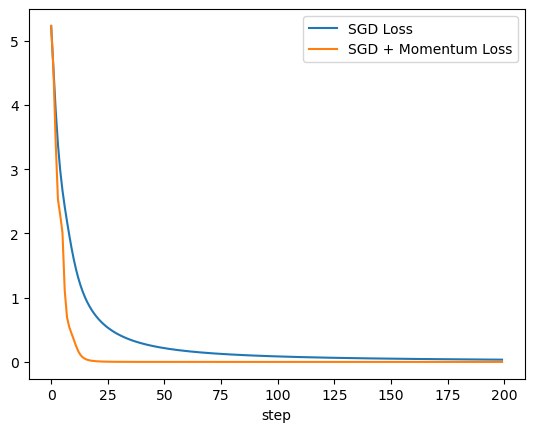

In [28]:
import pandas as pd
import numpy as np

sgd_loss_arr = np.array([loss.data for loss in progression_with_gd], dtype=float)
momentum_loss_arr = np.array([loss.data for loss in progression_with_gd_and_momentum], dtype=float)

loss_df = pd.DataFrame({
    "SGD Loss": sgd_loss_arr,
    "SGD + Momentum Loss": momentum_loss_arr,
})

loss_df.index.name = "step"

print(loss_df.dtypes)
print(loss_df.head())

loss_df.plot()


In [208]:
# Now we introduce the ADAM - or adaptive momentum estimation. 
# Unlike before we now consider the second moment of the gradient or the variance as way to inform our gradient descent 
# we also include two addtional parameters - the bias adjusted first and second moments that we will use to tune our mlp

In [42]:
'''
as per the adam paper we init our parameters to 0
m = 0
v = 0
now we have two additional maps to keep track of these as they are used in the bias corrected terms 
m_hat = m / (1- beta^{t}_{1})
v_hat = m / (1- beta^{t}_{2})
'''

def adam(neural_net, params):
    for p in neural_net.parameters():
        m = params.beta_1 * params.m_history[p] + (1 - params.beta_1)*p.grad
        v = params.beta_2 * params.v_history[p] + (1 - params.beta_2)*p.grad**2
        params.m_history[p] = m
        params.v_history[p] = v
        m_hat = m/ (1 - params.beta_1**params.timestep_t) 
        v_hat = v/ (1 - params.beta_2**params.timestep_t) # remember its B_{1/2} ** t ( its the decay portion for the velocity )
        p.data -= params.learning_rate * m_hat/ (v_hat**.5 + params.eps)
        
    #REMEMBER - the bias correction is influenced by the number of iterations we have trained 
    # realistically we would probably have this outside of our algo implemntation as the above is the update loop for the params
    # which constitutes one step in the training process
    params.timestep_t +=1

# As a result we will need to subclass hyper params to include the new params
class AdamHyperParams(HyperParams):
    def __init__(self, learning_rate, momentum_weight = 1, training_iterations=200):
        super().__init__(learning_rate, momentum_weight, training_iterations)
        self.beta_1 = .9
        self.beta_2 = 0.999
        self.timestep_t = 1
        self.eps = 1e-8 # to prevent divide by zero errors
        self.m_history= defaultdict(float)
        self.v_history= defaultdict(float)

        
# So a better way would be define a step function from the innerds of the training_loop function
def step(neural_net, xs, y_hat, optimization_method, _loss, hyper_params):
    ''' What we do during one iteration of learning '''
    y_pred = [neural_net(x) for x in xs]
    loss = _loss(y_pred, y_hat)
    for p in neural_net.parameters():
        p.grad = 0
    loss.backward()
    optimization_method(neural_net, hyper_params)
    return loss.data
    
def training_loop_with_adam(neural_net, xs, y_hat, params):
    loss_fn = lambda y_pred, y_hats: sum((y - y_true)**2 for y, y_true in zip(y_pred, y_hats)) 
    loss_history = []
    for t in range(params.training_iterations):
        loss_history.append(step(neural_net, xs, y_hat, adam, loss_fn, params))
    return loss_history
        
        
    

        
    

In [55]:
model_adam = MLP(3, [4, 4, 1], seed=seed)
adam_params = AdamHyperParams(
    learning_rate=0.09,
    training_iterations=200
)

progression_with_adam = training_loop_with_adam(model_adam,xs,ys,adam_params)

In [56]:
# comparing to the SGD variations:
loss_df = pd.DataFrame({
    "SGD Loss": sgd_loss_arr,
    "SGD + Momentum Loss": momentum_loss_arr,
})
adam_loss_series = pd.Series(progression_with_adam, dtype=float, name="ADAM")
# Concatenate horizontally
loss_df = pd.concat([loss_df, adam_loss_series], axis=1)

SGD Loss               float64
SGD + Momentum Loss    float64
ADAM                   float64
dtype: object
      SGD Loss  SGD + Momentum Loss      ADAM
step                                         
195   0.036674             0.000549  0.000098
196   0.036440             0.000548  0.000098
197   0.036209             0.000547  0.000097
198   0.035981             0.000546  0.000097
199   0.035755             0.000545  0.000097


<Axes: xlabel='step'>

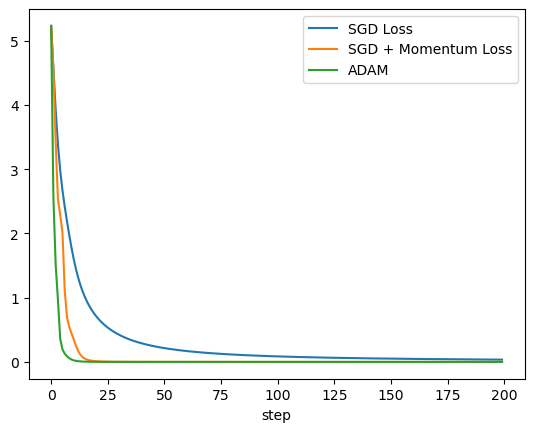

In [57]:
loss_df.index.name = "step"

print(loss_df.dtypes)
print(loss_df.tail())

loss_df.plot()